In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix

In [ ]:
df = pd.read_csv(r"C:\Users\KEERTHI SRI S\OneDrive\Desktop\AI_Data_Journey\2Months_of_ML\tested.csv")
df = df[['Pclass','Sex','Age','Fare','Survived']]
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Fare'] = df['Fare'].fillna(df['Fare'].mean())
df['Fare'] = np.log1p(df['Fare'])
df = pd.get_dummies(df, drop_first=True)
print(df.head())

   Pclass   Age      Fare  Survived  Sex_male
0       3  34.5  2.178064         0      True
1       3  47.0  2.079442         1     False
2       2  62.0  2.369075         0      True
3       3  27.0  2.268252         0      True
4       3  22.0  2.586824         1     False



Linear Regression Results:
     Actual  Predicted
0  2.107689   2.312549
1  5.358177   4.288598
2  2.169054   2.309739
3  2.185579   2.319575
4  2.578951   2.578179
MSE: 0.37502557898371464


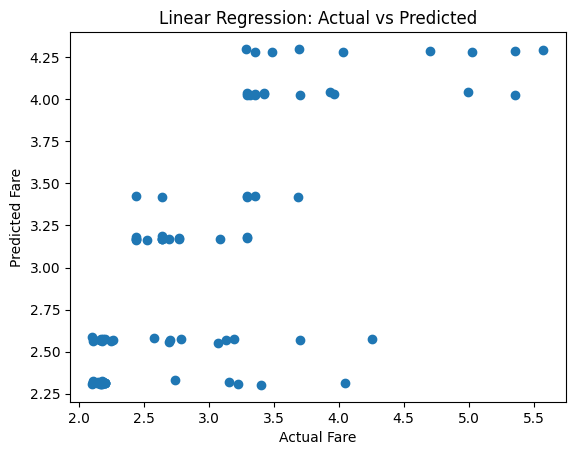

In [ ]:

X_lr = df.drop('Fare', axis=1)
y_lr = df['Fare']
X_train, X_test, y_train, y_test = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42
)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
result_lr = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
print("\nLinear Regression Results:")
print(result_lr.head())
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()


Logistic Regression Results:
   Actual  Predicted
0       0          0
1       1          1
2       0          0
3       0          0
4       1          1
Accuracy: 1.0


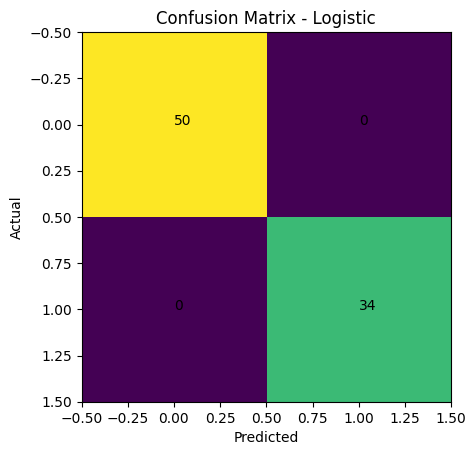

In [ ]:

X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)
result_log = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
print("\nLogistic Regression Results:")
print(result_log.head())
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm)
plt.title("Confusion Matrix - Logistic")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j])
plt.show()


KNN Results:
   Actual  Predicted
0       0          0
1       1          1
2       0          0
3       0          0
4       1          1
Accuracy: 1.0


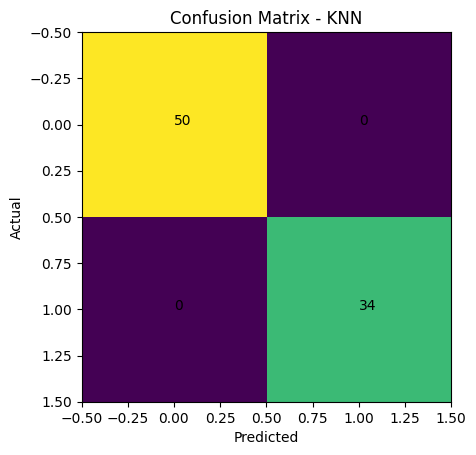

In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)
result_knn = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
print("\nKNN Results:")
print(result_knn.head())
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm)
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j])
plt.show()